<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/pytorch/2D_Decision_Boundary_Classifier_(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Modules
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
# More as we go on

[[-0.3756528  -0.04355335]
 [-1.2328442  -0.17618188]
 [-1.42693068 -1.15687614]
 ...
 [-0.53247421 -1.38615286]
 [-0.89835507 -1.90800586]
 [-0.05080225 -1.49157047]]


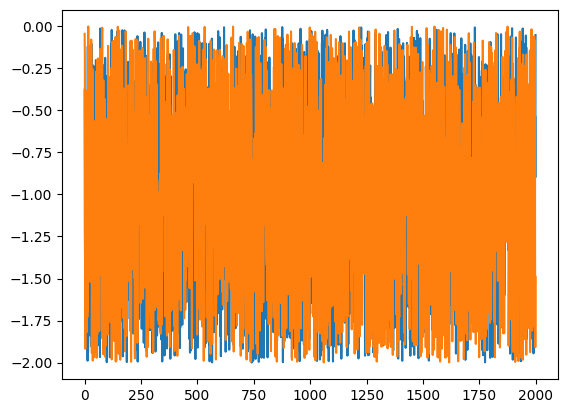

In [17]:
# Define the Dataset
# Circle equation: x^2 + y^2 < 1 -->, else 0
X = -2 * np.random.random_sample((2000,2))
print(X)
plt.plot(X)
plt.show()
# Sanitation Check
X = np.where(X > 2, 1, X)
y = []
for a in X:
  if a[0]**2 + a[1]**2 < 1:
    y.append(1)
  else:
    y.append(0)

In [18]:
# Convert to tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
print(X)
print(y)

tensor([[-0.3757, -0.0436],
        [-1.2328, -0.1762],
        [-1.4269, -1.1569],
        ...,
        [-0.5325, -1.3862],
        [-0.8984, -1.9080],
        [-0.0508, -1.4916]])
tensor([1., 0., 0.,  ..., 0., 0., 0.])


In [22]:
# Manual train-test split
train_size = int(0.8 * len(y))
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([1600, 2])
torch.Size([1600])
torch.Size([400, 2])
torch.Size([400])


In [40]:
# Define the model
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=32)
    self.layer2 = nn.ReLU()
    self.layer3 = nn.Linear(in_features=32, out_features=32)
    self.layer4 = nn.ReLU()
    self.layer5 = nn.Linear(in_features=32, out_features=1)

  def forward(self, x):
    return self.layer5(self.layer4(self.layer3(self.layer2(self.layer1(x)))))

In [41]:
MLPmodel = MLP()
MLPmodel.parameters()

<generator object Module.parameters at 0x7e4696cc6a40>

In [43]:
# Loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=MLPmodel.parameters(), lr=1e-2)

In [45]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
#!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [49]:
# Training Loop
epochs = 300
for epoch in range(epochs):

  MLPmodel.train()
  y_logits = MLPmodel(X_train)
  y_pred_probs = torch.sigmoid(y_logits)
  y_pred_labels = torch.round(y_pred_probs)

  acc = acc_fn(y_pred_labels.squeeze(1), y_train)
  loss = loss_fn(y_logits.squeeze(1), y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ## Evaluation
  with torch.no_grad():
    MLPmodel.eval()
    y_logits = MLPmodel(X_train)
    y_pred_probs = torch.sigmoid(y_logits)
    y_pred_labels = torch.round(y_pred_probs)

    acc = acc_fn(y_pred_labels.squeeze(1), y_train)
    loss = loss_fn(y_logits.squeeze(1), y_train)
    if epoch % 100 == 0:
      print(f"Epoch: {epoch}. Acc:{acc}. Loss:{loss}")

Epoch: 0. Acc:0.8174999952316284. Loss:0.6823778748512268
Epoch: 100. Acc:0.9937499761581421. Loss:0.02592870220541954
Epoch: 200. Acc:0.9987499713897705. Loss:0.011451678350567818


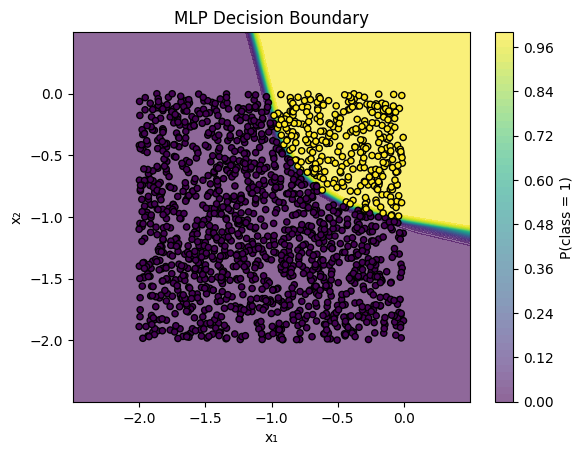

In [50]:
import matplotlib.pyplot as plt

# Put model in evaluation mode
MLPmodel.eval()

# Convert training data to NumPy
X_np = X_train.detach().cpu().numpy()
y_np = y_train.detach().cpu().numpy()

# Define plotting range
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

# Create grid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Forward pass on grid
with torch.no_grad():
    logits = MLPmodel(grid_tensor)
    probs = torch.sigmoid(logits).view(xx.shape)

# Plot decision boundary
plt.figure()
plt.contourf(xx, yy, probs.numpy(), levels=50, alpha=0.6)
plt.colorbar(label="P(class = 1)")

# Plot data points
plt.scatter(
    X_np[:, 0],
    X_np[:, 1],
    c=y_np,
    edgecolors="k",
    s=20
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("MLP Decision Boundary")
plt.show()